# Dask Bag

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Лекция "Map-Reduce"
* https://docs.dask.org/en/latest/bag.html
* Jesse C. Daniel. Data Science with Python and Dask.
* https://docs.dask.org/en/stable/generated/dask.bag.read_text.html
* https://docs.dask.org/en/stable/generated/dask.bag.Bag.distinct.html
* https://docs.dask.org/en/stable/generated/dask.bag.Bag.count.html
* https://www.nltk.org/_modules/nltk/tokenize/regexp.html
* https://docs.dask.org/en/stable/generated/dask.bag.Bag.mean.html
* https://www.crummy.com/software/BeautifulSoup/bs4/doc/
* https://docs.dask.org/en/stable/generated/dask.bag.Bag.frequencies.html
* https://pypi.org/project/wordcloud/

## Задачи для совместного разбора

In [ ]:
import dask.bag as db
import json

In [ ]:
with open("./data/posts.json") as fp:
    posts = json.load(fp)

1. Посчитайте длину (в кол-ве символов) каждого заголовка.

In [ ]:
[len(post['title']) for post in posts][:5]

[74, 12, 59, 20, 18]

In [ ]:
def get_len(x):
    return len(x['title'])

list(map(get_len, posts))[:5]

[74, 12, 59, 20, 18]

![image-2.png](attachment:image-2.png)

In [ ]:
bag = db.from_sequence(posts, npartitions=4)
bag

dask.bag<from_sequence, npartitions=4>

In [ ]:
# bag.map(get_len).compute()
bag.map(
    lambda post: len(post['title'])
).take(5)

(74, 12, 59, 20, 18)

2. Выведите id постов, длина заголовков которых не более 15 символов.

In [ ]:
[post['id'] for post in posts if len(post['title']) <= 15]

[2, 40, 41, 57, 91]

In [ ]:
list(
    map(
        lambda post: post['id'],
        filter(lambda post: len(post['title']) <= 15, posts)
    )
)

[2, 40, 41, 57, 91]

![image-2.png](attachment:image-2.png)

In [ ]:
bag.filter(
    lambda post: len(post['title']) <= 15
).map(
    lambda post: post['id']
).take(5, npartitions=-1)

(2, 40, 41, 57, 91)

## Лабораторная работа 9

__При решении данных задач не подразумевается использования циклов или генераторов Python в ходе работы с пакетами `numpy`, `pandas` и `dask`, если в задании не сказано обратного. Решения задач, в которых для обработки массивов `numpy`, структур `pandas` или структур `dask` используются явные циклы (без согласования с преподавателем), могут быть признаны некорректными и не засчитаны.__

В ходе выполнения все операции вычислений проводятся над `dask.bag` и средствами пакета `dask`, если в задании не сказано обратного. Переход от `dask.bag` к `pd.DataFrame` возможен исключительно для демонстрации результата в конце решения задачи. Если в задаче используются результаты выполнения предыдущих задач, то подразумевается, что вы используете результаты в виде `dask.bag` (то есть то, что было получено до вызова `compute`, а не после).

<p class="task" id="1"></p>

1\. В файлах архива `reviews_full.zip` находятся файлы, содержащие информацию об отзывах к рецептам в формате JSON Lines. Отзывы разделены на файлы в зависимости от оценки (например, в файле `reviews_1.json` находятся отзывы с оценкой 1). Считайте файлы из этого архива (предварительно разархивировав) в виде `dask.bag`. Преобразуйте текстовое содержимое файлов с помощью модуля `json`. Выведите на экран первые 5 элементов полученного `bag`.

Примечание: при необходимости вы можете разархивировать архив любым удобным способом.

In [ ]:
import dask.bag as db
import json

In [ ]:
bag = db.read_text("./data/reviews_full/*.json").map(json.loads)

In [ ]:
bag.take(5)

({'user_id': 452355,
  'recipe_id': 292657,
  'date': '2016-05-08',
  'review': 'WOW!!! This is the best. I have never been able to make homemade enchiladas that taste like the Mexican restaurants. I made this last night for my family and they said they will never have enchiladas at the Mexican Restaurants again. Thanks for sharing.'},
 {'user_id': 329304,
  'recipe_id': 433404,
  'date': '2006-06-14',
  'review': 'This was good but the dressing needed something and I found it to be a little too sweet, next time I will experiment with some garlic and herbs and reduce the sugar slightly, thanks for sharing kcdlong!...Kitten'},
 {'user_id': 227932,
  'recipe_id': 2008187,
  'date': '1985-11-19',
  'review': 'Very good,it was a hit for my family. I used 6 cloves of garlic and had 1 lb beef and  Johnsonville sausage,1/2 lb hot and  1/2 lb honey garlic( which I wanted to use). That was a perfect combo for us. The sausage gave it nice flavor No guestion , I will be making this often.'},
 {'u

<p class="task" id="2"></p>

2\. Модифицируйте функцию разбора JSON таким образом, чтобы в каждый словарь c информацией об отзыве добавить ключ `rating`. Значение получите на основе названия файла (см. аргумент `include_path` функции `read_text`), использовав для этого регулярное выражение. При создании `bag` разбейте набор данных на сегменты размером 128 MiB (см. аргумент `blocksize`).  Выведите на экран первые 5 элементов полученного `bag` и количество сегментов в нем.

In [ ]:
import re

bag = db.read_text("./data/reviews_full/*.json", include_path=True, blocksize='128MiB').map(
    lambda x: json.loads(x[0]) | {'rating': re.search(r'reviews_(\d).json', x[1]).group(1)}
)
bag.take(5)

({'user_id': 452355,
  'recipe_id': 292657,
  'date': '2016-05-08',
  'review': 'WOW!!! This is the best. I have never been able to make homemade enchiladas that taste like the Mexican restaurants. I made this last night for my family and they said they will never have enchiladas at the Mexican Restaurants again. Thanks for sharing.',
  'rating': '0'},
 {'user_id': 329304,
  'recipe_id': 433404,
  'date': '2006-06-14',
  'review': 'This was good but the dressing needed something and I found it to be a little too sweet, next time I will experiment with some garlic and herbs and reduce the sugar slightly, thanks for sharing kcdlong!...Kitten',
  'rating': '0'},
 {'user_id': 227932,
  'recipe_id': 2008187,
  'date': '1985-11-19',
  'review': 'Very good,it was a hit for my family. I used 6 cloves of garlic and had 1 lb beef and  Johnsonville sausage,1/2 lb hot and  1/2 lb honey garlic( which I wanted to use). That was a perfect combo for us. The sausage gave it nice flavor No guestion , I 

In [ ]:
bag.npartitions

25

<p class="task" id="3"></p>

3\. Посчитайте, сколько различных пользователей оставляли отзывы. Выведите это количество на экран.

In [ ]:
num_users = bag.map(lambda x: x['user_id']).distinct().count()
num_users.compute()

226570

<p class="task" id="4"></p>

4\. Создайте версию `bag` из задания 2, в которой сохранены только отзывы, оставленные в 2014 и 2015 годах. Посчитайте и выведите на экран долю, которую составляют отзывы, оставленные в 2014 и 2015 году, среди всех отзывов.

In [ ]:
bag_2014_2015 = db.read_text("./data/reviews_full/*.json", include_path=True, blocksize='128MiB').map(
    lambda x: json.loads(x[0]) | {'rating': re.search(r'reviews_(\d).json', x[1]).group(1)}
).filter(
    lambda x: re.search(r'2014|2015', x['date']) is not None
)

bag_2014_2015.count().compute() / bag.count().compute()

0.08117811237929945

<p class="task" id="5"></p>

5\. Для отзывов, оставленных в мае 2013 года, выполните предобработку:
   * приведите строки к нижнему регистру;
   * обрежьте пробельные символы в начале и конце строки;
   * удалите все символы, кроме английских букв и пробелов.
   
Посчитайте и выведите на экран среднюю длину этих отзывов после предобработки. Если текстовое содержимое отзыва отсутствует, считайте, что длина отзыва равна нулю.

In [ ]:
def preprocess(review):
    review['review'] = re.sub(r'^\s+|\s+$', '', review['review'].lower())
    review['review'] = re.sub(r'[^a-z ]', '', review['review'])
    return review

mean_length_before = bag.map(
    lambda x: len(x['review'] or '')
).mean().compute()

bag_may_2013 = bag.filter(
    lambda x: re.search(r'2013-05', x['date']) is not None
).map(preprocess)

mean_length_after = bag_may_2013.map(
    lambda x: len(x['review'] or '')
).mean().compute()

mean_length_before, mean_length_after

(278.37090622840196, 268.9917584273458)

<p class="task" id="6"></p>

6\. В файле `food.txt` представлен список из 329 ссылок на страницы Википедии, посвященные различным блюдам. Получив основное текстовое содержимое этих страниц, выясните, какие топ-30 слов используются в этих статьях чаще всего. Выведите на экран эти слова и их частоты.

Для разбиения текста на слова воспользуйтесь токенизатором `tokenizer`. В качестве препроцессинга приведите все слова к нижнему регистру и удалите стоп-слова, входящие в список английских стоп-слов из `nltk`.

При решении задачи не используйте параллельных вычислений. Измерьте время выполнения решения.

Примечание: под основным содержимым страницы подразумевается содержимое тега `div`, имеющего класс `mw-parser-output`.

In [ ]:
from bs4 import BeautifulSoup
import requests
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
stopwords_en = stopwords.words('english')
tokenizer = RegexpTokenizer(r'\w+')
from collections import Counter

In [ ]:
def get_text(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    text = soup.find('div', class_='mw-parser-output').get_text()
    return text

class TextProcessor:
    def __init__(self, stopwords, tokenizer):
        self.stopwords = stopwords
        self.tokenizer = tokenizer

    def __call__(self, text):
        tokens = self.tokenizer.tokenize(text.lower())
        return [token for token in tokens if token not in self.stopwords]

In [ ]:
with open('./data/food.txt') as fp:
    links = fp.read().splitlines()

text_processor = TextProcessor(stopwords_en, tokenizer)

In [ ]:
%%time
word_counts_def = []
for link in links:
    text = get_text(link)
    word_counts_def.extend(text_processor(text))

word_counts_def = Counter(word_counts_def)
word_counts_def.most_common(30)

CPU times: user 35.2 s, sys: 752 ms, total: 35.9 s
Wall time: 4min 49s


[('nasi', 8510),
 ('goreng', 4647),
 ('ayam', 4490),
 ('sate', 3414),
 ('mi', 3249),
 ('pizza', 2765),
 ('soto', 2761),
 ('roti', 2512),
 ('indonesian', 2494),
 ('rice', 2471),
 ('edit', 1977),
 ('food', 1853),
 ('es', 1713),
 ('ikan', 1708),
 ('kari', 1708),
 ('retrieved', 1689),
 ('babi', 1671),
 ('tahu', 1586),
 ('cheese', 1542),
 ('rujak', 1528),
 ('bubur', 1420),
 ('teh', 1358),
 ('soup', 1331),
 ('sayur', 1327),
 ('dishes', 1305),
 ('bakar', 1270),
 ('sambal', 1245),
 ('list', 1233),
 ('lumpia', 1228),
 ('pindang', 1220)]

<p class="task" id="7"></p>

7\. Решите задачу 6, распараллелив процесс получения текста страницы из Википедии при помощи `dask.bag`.Выведите на экран полученный список топ-30 слов и их частоты. Для подсчета частот воспользуйтесь методом `Bag.frequencies`. Измерьте время выполнения решения.

Подсказка: обратите внимание на количество сегментов в `Bag`, который вы создали.

In [ ]:
bag = db.from_sequence(links).map(get_text).map(text_processor)
combined_bag = bag.flatten()
word_counts = combined_bag.frequencies()
top_words = word_counts.topk(30, key=lambda x: x[1])

In [ ]:
%%time
top_words.compute()

CPU times: user 281 ms, sys: 115 ms, total: 396 ms
Wall time: 46.8 s


[('nasi', 8510),
 ('goreng', 4647),
 ('ayam', 4490),
 ('sate', 3414),
 ('mi', 3249),
 ('pizza', 2765),
 ('soto', 2761),
 ('roti', 2512),
 ('indonesian', 2494),
 ('rice', 2471),
 ('edit', 1977),
 ('food', 1853),
 ('es', 1713),
 ('ikan', 1708),
 ('kari', 1708),
 ('retrieved', 1689),
 ('babi', 1671),
 ('tahu', 1586),
 ('cheese', 1542),
 ('rujak', 1528),
 ('bubur', 1420),
 ('teh', 1358),
 ('soup', 1331),
 ('sayur', 1327),
 ('dishes', 1305),
 ('bakar', 1270),
 ('sambal', 1245),
 ('list', 1233),
 ('lumpia', 1228),
 ('pindang', 1220)]

<p class="task" id="8"></p>

8\. Визуализируйте результат, полученный в задаче 6 или 7, в виде облака слов. Для генерации облака слов вы можете воспользоваться пакетом [wordcloud](https://pypi.org/project/wordcloud/). Обратите внимание, что размер слова на визуализации должен зависеть от частоты использования этого слова.

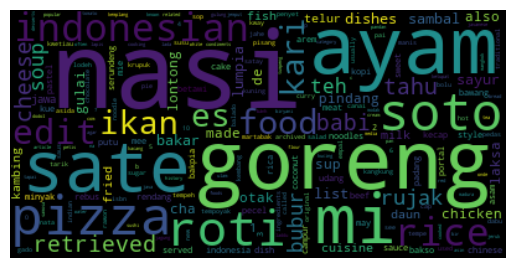

In [ ]:
import wordcloud
import matplotlib.pyplot as plt

wc = wordcloud.WordCloud()
wc.generate_from_frequencies(word_counts_def)
wc.to_image()

plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()